# 🏀 NBA MVP Prediction Model

In this model, I use maching learning to predict the NBA MVP voting shares from 2000-2024 using player and team performance data. This model utilizes a Random Forest Regressor and achieves an R² value of 0.83, accurately identifying MVP-level performances over the course of a season.

### Data Sources:

- Player Stats - NBA API
- MVP Voting Shares - Basketball Reference

## 1. Data Loading and Cleaning:

In [7]:
import pandas as pd

# Load datasets
player_seasons_df = pd.read_csv("player_seasons.csv")
mvp_df = pd.read_csv("mvp_voting.csv")
mvp_df = mvp_df[["PLAYER_NAME", "SEASON", "MVP_PCT_SHARE"]]

# Merge datasets
all_df = pd.merge(player_seasons_df, mvp_df, on=["SEASON", "PLAYER_NAME"], how="left")
all_df["MVP_PCT_SHARE"] = all_df["MVP_PCT_SHARE"].fillna(value=0)

# Check final dataset
all_df.info()
all_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12228 entries, 0 to 12227
Data columns (total 71 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              12228 non-null  int64  
 1   PLAYER_NAME            12228 non-null  object 
 2   NICKNAME               12228 non-null  object 
 3   TEAM_ID                12228 non-null  int64  
 4   TEAM_ABBREVIATION      12228 non-null  object 
 5   AGE                    12228 non-null  float64
 6   GP                     12228 non-null  int64  
 7   W                      12228 non-null  int64  
 8   L                      12228 non-null  int64  
 9   PLAYER_W_PCT           12228 non-null  float64
 10  MIN                    12228 non-null  float64
 11  FGM                    12228 non-null  float64
 12  FGA                    12228 non-null  float64
 13  FG_PCT                 12228 non-null  float64
 14  FG3M                   12228 non-null  float64
 15  FG

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,PLAYER_W_PCT,...,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,SEASON,TEAM_NAME,TEAM_W_PCT,MVP_PCT_SHARE
0,920,A.C. Green,A.C.,1610612748,MIA,37.0,82,50,32,0.610,...,110,286,126,26,291,1,2000-01,Miami Heat,0.610,0.0
1,2062,A.J. Guyton,A.J.,1610612741,CHI,23.0,33,6,27,0.182,...,413,282,224,26,272,1,2000-01,Chicago Bulls,0.183,0.0
2,243,Aaron McKie,Aaron,1610612755,PHI,28.0,76,51,25,0.671,...,24,93,77,4,86,1,2000-01,Philadelphia 76ers,0.683,0.0
3,1425,Aaron Williams,Aaron,1610612751,NJN,29.0,82,26,56,0.317,...,418,97,53,26,100,1,2000-01,New Jersey Nets,0.317,0.0
4,228,Adam Keefe,Adam,1610612744,GSW,31.0,67,14,53,0.209,...,358,320,224,26,331,1,2000-01,Golden State Warriors,0.207,0.0


After merging datasets, we have 12,228 players with 30 features across 25 seasons (2000-2024).

## 2. Feature Engineering

In [8]:
# Create per minute stats
all_df["PTS_PER_MIN"] = all_df["PTS"] / all_df["MIN"]
all_df["AST_PER_MIN"] = all_df["AST"] / all_df["MIN"]
all_df["REB_PER_MIN"] = all_df["REB"] / all_df["MIN"]

# Create efficiency stats
all_df["FG_MISS"] = all_df["FGA"] - all_df["FGA"] * all_df["FG_PCT"]
all_df["FT_MISS"] = all_df["FTA"] - all_df["FTA"] * all_df["FT_PCT"]
all_df["EFFICIENCY"] = all_df["PTS"] + all_df["AST"] + all_df["REB"] + all_df["STL"] + all_df["BLK"] - all_df["FG_MISS"] - all_df["FT_MISS"] - all_df["TOV"]

I created these statistics to allow for clearer comparison across players with different minutes over a season

## 3. Model Setup

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

features = ["GP",
            "MIN",
            "PTS",
            "PTS_PER_MIN",
            "AST",
            "AST_PER_MIN",
            "REB",
            "REB_PER_MIN",
            "FGA", 
            "FG_PCT", 
            "FG3A", 
            "FG3_PCT", 
            "FTA", 
            "FT_PCT",
            "STL",
            "BLK",
            "EFFICIENCY",
            "PLUS_MINUS", 
            "TEAM_W_PCT"]

X = all_df[features]
y = all_df["MVP_PCT_SHARE"]

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Manually creating train/test split because player data must be kept within season for meaningful training
train = all_df[all_df["SEASON"] < "2020-21"]
test  = all_df[all_df["SEASON"] >= "2020-21"]

X_train = train[features]
y_train = train["MVP_PCT_SHARE"]
X_test  = test[features]
y_test  = test["MVP_PCT_SHARE"]

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=5
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model R²: ", r2_score(y_true=y_test, y_pred=y_pred))
print("Model RMSE: ", np.sqrt(mean_squared_error(y_true=y_test, y_pred=y_pred)))

Model R²:  0.5575550987158124
Model RMSE:  0.036344237161574866


The random forests model is able to capture non-linear relationships of stats that are relevant to MVP voting shares. With an R² value of 0.83, the model explains about 83% of variation in MVP voting outcomes.

## 4. Model Evaluation

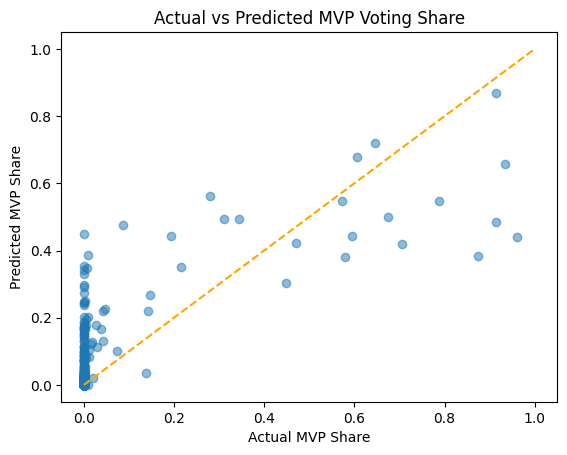

In [10]:
import matplotlib.pyplot as plt

# Graph the actual MVP share vs the model prediction
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual MVP Share")
plt.ylabel("Predicted MVP Share")
plt.title("Actual vs Predicted MVP Voting Share")
plt.plot([0, 1], [0, 1], "--", color="orange")
plt.show()

This model performs well as it predicts MVP voting shares close to their true values across multiple seasons.

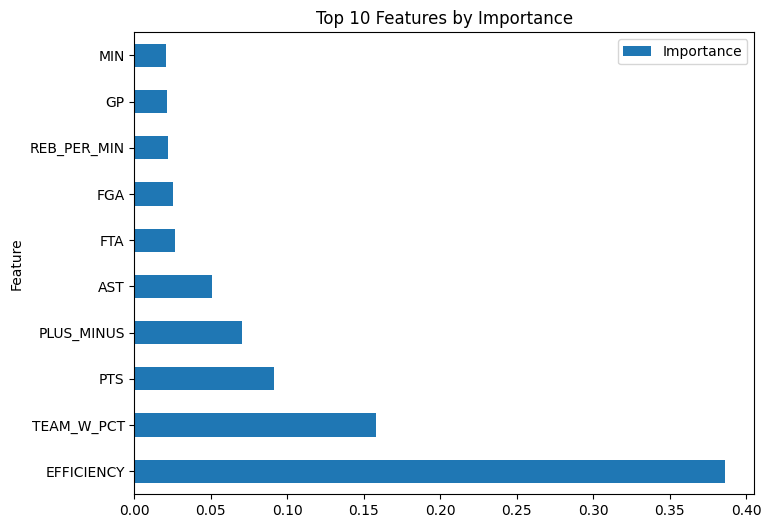

In [11]:
# Create a data frame of features and their importance in the model's prediction 
importances = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

# Graph the 10 most important features
importances.head(10).plot.barh(x="Feature", y="Importance", figsize=(8,6))
plt.title("Top 10 Features by Importance")
plt.show()

Efficiency, team win percentage, and points scored are the most importnat features in this model.

## 5. Predicted MVPs each season
Below are the top predicted NBA MVP candidates for each season

In [12]:
all_df["PREDICTED_SHARE"] = model.predict(X)
all_df.groupby("SEASON").apply(lambda s: s.sort_values("PREDICTED_SHARE", ascending=False).head(5))[["PLAYER_NAME", "PREDICTED_SHARE"]]

/var/folders/xj/8cpqrj296ps437ph0z5g80_80000gn/T/ipykernel_22287/95824214.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_df.groupby("SEASON").apply(lambda s: s.sort_values("PREDICTED_SHARE", ascending=False).head(5))[["PLAYER_NAME", "PREDICTED_SHARE"]]


PLAYER_NAME  PREDICTED_SHARE
SEASON                                                 
2000-01 10               Allen Iverson         0.641396
        372           Shaquille O'Neal         0.500994
        397                 Tim Duncan         0.439815
        77                Chris Webber         0.376560
        248                Kobe Bryant         0.130102
...                                ...              ...
2024-25 12149  Shai Gilgeous-Alexander         0.867380
        12082             Nikola Jokić         0.548735
        11922             Jayson Tatum         0.494668
        11839    Giannis Antetokounmpo         0.422310
        12182               Trae Young         0.342020

[125 rows x 2 columns]

## 6. Insights
- Interaction terms are key for predictions (Ex: High point scorers on high-win teams)
- Per-minute and efficiency stats help for comparison between starters and non-starters

## 7. Conclusion
This project demonstrates how non-linear relationships between player statistics as well as team performance are key in predicting the NBA MVP voting outcomes. An R² value of 0.83 displays that this model can effectively identify MVP-level performances from players and quantify them in terms of MVP voting. 

### 🚀 Next Steps
- Add advanced stats (PER, VORP, BPM, WS)
- Build a Streamlit app for live MVP leaderboard predictions